In [1]:
# Cell 2: alignment/cropping helper
from src.measure_ir import align_irs_by_distance

In [2]:
# Cell 1: imports + load data

import numpy as np
import matplotlib.pyplot as plt

data = np.load("./data/multiple_irs.npz")

fs = float(data["fs"])
panel_to_err_cm = float(data["panel_to_err_cm"])

errors_raw = [
    data[f"error{i}"]
    for i in range(1, 6)
]

refs_raw = [
    data[f"ref{i}"]
    for i in range(1, 6)
]

print("fs:", fs)
print("panel_to_err_cm:", panel_to_err_cm)

for i, ir in enumerate(errors_raw, 1):
    print(f"error{i}: {len(ir)} samples")

fs: 96000.0
panel_to_err_cm: 4.5
error1: 1535999 samples
error2: 1535999 samples
error3: 1535999 samples
error4: 1535999 samples
error5: 1535999 samples


In [3]:
ir_len=256

In [4]:
# Cell 3: align all 5 measurements

errors = []
refs = []

for error_raw, ref_raw in zip(errors_raw, refs_raw):

    error_aligned, ref_aligned = align_irs_by_distance(
        error_raw,
        ref_raw,
        distance_cm=panel_to_err_cm,
        ir_len=ir_len,
        fs=fs,
    )

    errors.append(error_aligned)
    refs.append(ref_aligned)

for i, ir in enumerate(errors, 1):
    peak = np.argmax(np.abs(ir))

    print(
        f"IR {i}: peak = {peak} samples "
        f"({1000 * peak / fs:.3f} ms)"
    )

IR 1: peak = 13 samples (0.135 ms)
IR 2: peak = 13 samples (0.135 ms)
IR 3: peak = 13 samples (0.135 ms)
IR 4: peak = 13 samples (0.135 ms)
IR 5: peak = 13 samples (0.135 ms)


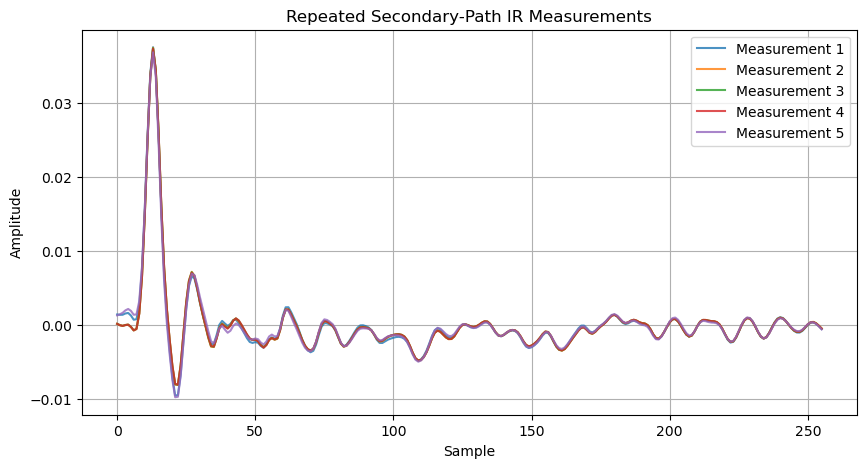

In [5]:
# Cell 4: plot aligned error-mic IRs

plt.figure(figsize=(10, 5))

for i, ir in enumerate(errors, 1):
    plt.plot(
        np.arange(len(ir)),
        ir,
        label=f"Measurement {i}",
        alpha=0.8,
    )

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Repeated Secondary-Path IR Measurements")
plt.grid()
plt.legend()
plt.show()

In [6]:
# Cell 5: FFTs

NFFT = 16384

f = np.fft.rfftfreq(NFFT, 1 / fs)

S = [
    np.fft.rfft(ir, n=NFFT)
    for ir in errors
]

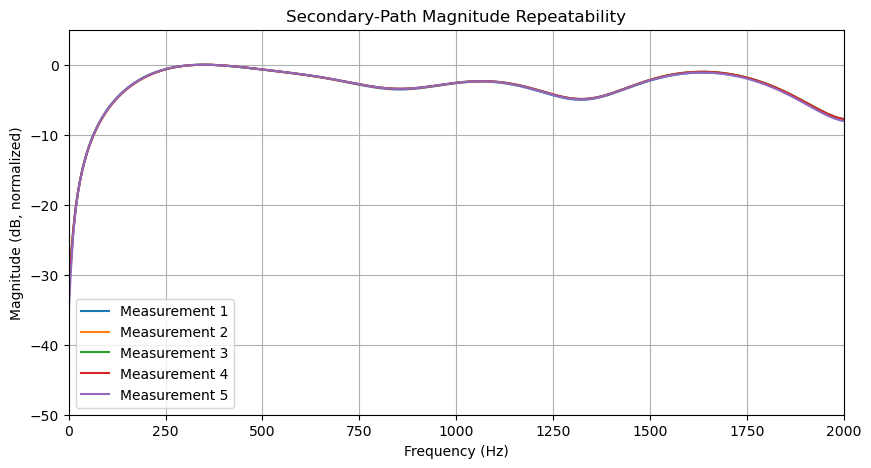

In [7]:
# Cell 6: magnitude responses

plt.figure(figsize=(10, 5))

for i, H in enumerate(S, 1):

    mag_db = 20 * np.log10(
        np.abs(H) + 1e-30
    )

    # normalize each measurement so we're comparing shape
    mag_db -= np.max(mag_db)

    plt.plot(
        f,
        mag_db,
        label=f"Measurement {i}",
    )

plt.xlim(0, 2000)
plt.ylim(-50, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB, normalized)")
plt.title("Secondary-Path Magnitude Repeatability")
plt.grid()
plt.legend()
plt.show()

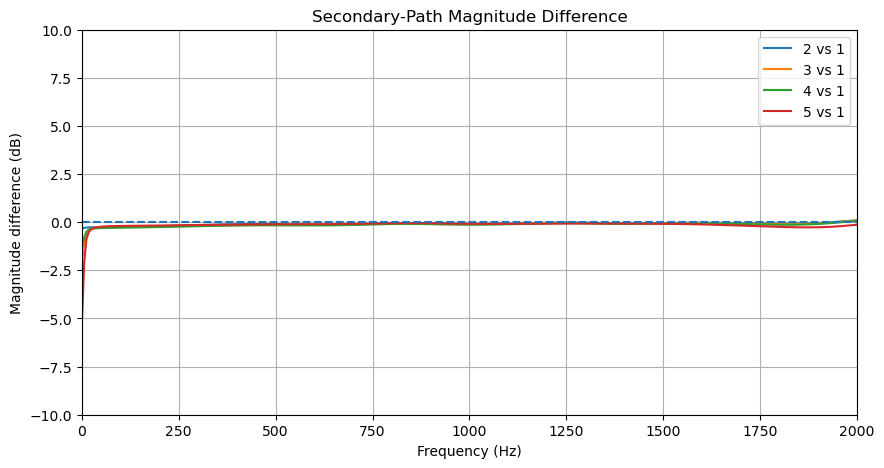

In [8]:
# Cell 7: magnitude difference relative to measurement 1

S0 = S[0]

plt.figure(figsize=(10, 5))

for i in range(1, len(S)):

    mag_diff_db = 20 * np.log10(
        (np.abs(S[i]) + 1e-30) /
        (np.abs(S0) + 1e-30)
    )

    plt.plot(
        f,
        mag_diff_db,
        label=f"{i+1} vs 1",
    )

plt.axhline(0, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(-10, 10)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude difference (dB)")
plt.title("Secondary-Path Magnitude Difference")
plt.grid()
plt.legend()
plt.show()

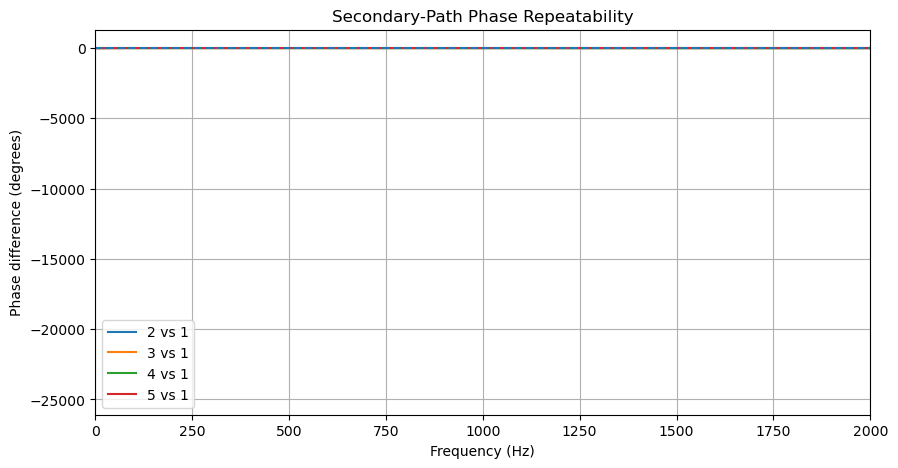

In [9]:
# Cell 8: phase difference relative to measurement 1

plt.figure(figsize=(10, 5))

for i in range(1, len(S)):

    phase_diff = np.unwrap(
        np.angle(S[i] / S0)
    )

    phase_diff_deg = np.degrees(
        phase_diff
    )

    plt.plot(
        f,
        phase_diff_deg,
        label=f"{i+1} vs 1",
    )

plt.axhline(0, linestyle="--")

plt.xlim(0, 2000)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase difference (degrees)")
plt.title("Secondary-Path Phase Repeatability")
plt.grid()
plt.legend()
plt.show()

In [10]:
# Cell 9: estimate equivalent timing offset from phase slope

fit_band = (f >= 300) & (f <= 2000)

for i in range(1, len(S)):

    phase_diff = np.unwrap(
        np.angle(S[i] / S0)
    )

    # phase in radians vs frequency in Hz
    slope, intercept = np.polyfit(
        f[fit_band],
        phase_diff[fit_band],
        1,
    )

    # phase slope = -2*pi*delay
    delay_seconds = -slope / (2 * np.pi)

    delay_samples = delay_seconds * fs

    print(
        f"Measurement {i+1} vs 1: "
        f"{delay_samples:.3f} samples "
        f"({delay_seconds * 1e6:.2f} us)"
    )

Measurement 2 vs 1: 0.952 samples (9.92 us)
Measurement 3 vs 1: 0.933 samples (9.72 us)
Measurement 4 vs 1: 0.954 samples (9.94 us)
Measurement 5 vs 1: -0.126 samples (-1.31 us)


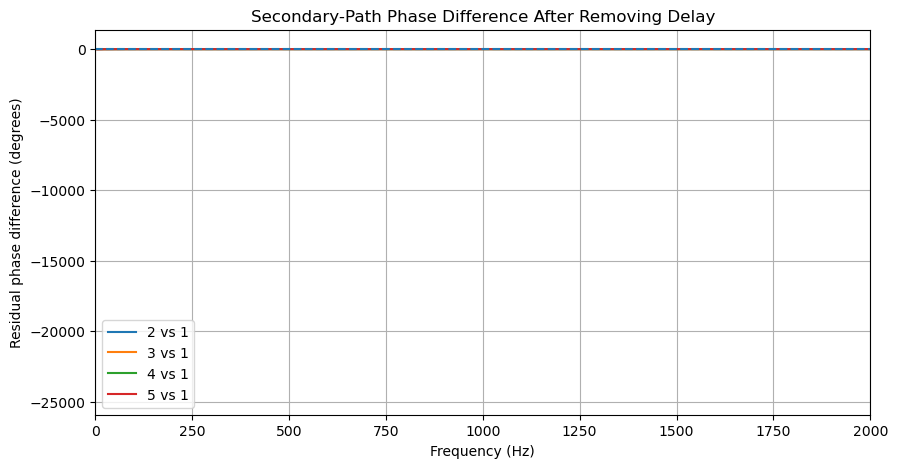

In [11]:
# Cell 10: phase difference after removing best-fit delay

plt.figure(figsize=(10, 5))

for i in range(1, len(S)):

    phase_diff = np.unwrap(
        np.angle(S[i] / S0)
    )

    slope, intercept = np.polyfit(
        f[fit_band],
        phase_diff[fit_band],
        1,
    )

    phase_fit = slope * f + intercept

    residual = phase_diff - phase_fit

    plt.plot(
        f,
        np.degrees(residual),
        label=f"{i+1} vs 1",
    )

plt.axhline(0, linestyle="--")

plt.xlim(0, 2000)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Residual phase difference (degrees)")
plt.title("Secondary-Path Phase Difference After Removing Delay")
plt.grid()
plt.legend()
plt.show()

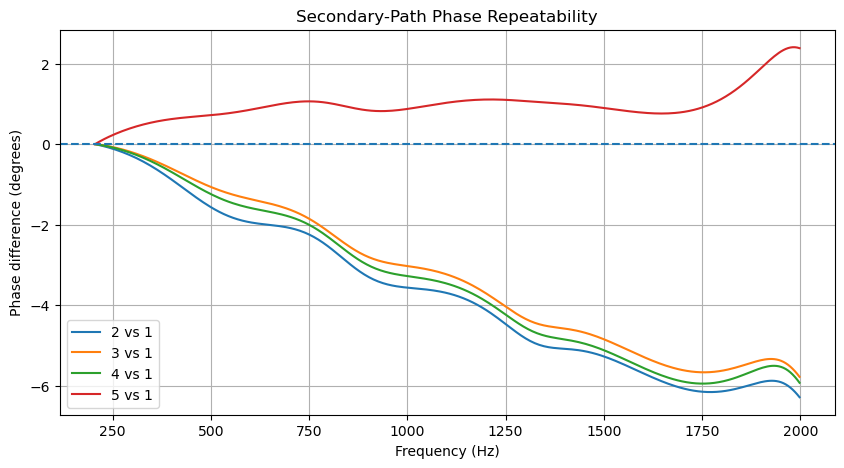

In [12]:
# Phase repeatability only where we actually care about it

band = (f >= 200) & (f <= 2000)

fb = f[band]

plt.figure(figsize=(10, 5))

for i in range(1, len(S)):

    ratio = S[i][band] / S0[band]

    phase_diff = np.unwrap(
        np.angle(ratio)
    )

    # Remove arbitrary constant phase offset so curves start at zero
    phase_diff -= phase_diff[0]

    plt.plot(
        fb,
        np.degrees(phase_diff),
        label=f"{i+1} vs 1",
    )

plt.axhline(0, linestyle="--")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase difference (degrees)")
plt.title("Secondary-Path Phase Repeatability")
plt.grid()
plt.legend()

plt.show()

2 vs 1: 0.978 samples
3 vs 1: 0.942 samples
4 vs 1: 0.969 samples
5 vs 1: -0.143 samples


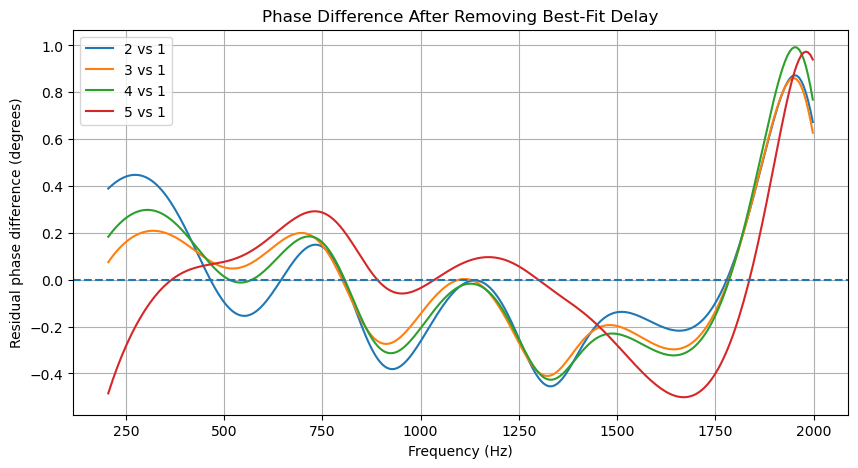

In [13]:
plt.figure(figsize=(10, 5))

for i in range(1, len(S)):

    ratio = S[i][band] / S0[band]

    phase_diff = np.unwrap(
        np.angle(ratio)
    )

    # Fit phase = slope*f + intercept
    slope, intercept = np.polyfit(
        fb,
        phase_diff,
        1
    )

    phase_fit = slope * fb + intercept

    residual = phase_diff - phase_fit

    delay_samples = (
        -slope / (2 * np.pi)
    ) * fs

    print(
        f"{i+1} vs 1: "
        f"{delay_samples:.3f} samples"
    )

    plt.plot(
        fb,
        np.degrees(residual),
        label=f"{i+1} vs 1",
    )

plt.axhline(0, linestyle="--")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Residual phase difference (degrees)")
plt.title("Phase Difference After Removing Best-Fit Delay")
plt.grid()
plt.legend()

plt.show()